# RetailPulse – Demand Forecasting

This notebook performs:
- Time-series analysis
- Demand forecasting
- Forecast evaluation
- Trend visualization

Module:
Forecasting & Inventory Optimization

In [159]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet

from statsmodels.tsa.arima.model import ARIMA

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings('ignore')

LOAD CLEANED DATASET

In [160]:
# Load cleaned dataset
import os

BASE_DIR = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(BASE_DIR, 'data', 'cleaned_retail_data.csv')

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (327362, 17)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,DayName,Hour,Weekend,RevenueCategory,OrderSizeCategory
0,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,2009,12,1,Tuesday,7,False,Medium Revenue,Large Order
1,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,2009,12,1,Tuesday,7,False,Medium Revenue,Large Order
2,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.60,2009,12,1,Tuesday,7,False,Medium Revenue,Medium Order
3,489435,22353,LUNCHBOX WITH CUTLERY FAIRY CAKES,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.60,2009,12,1,Tuesday,7,False,Medium Revenue,Medium Order
4,489436,21754,HOME BUILDING BLOCK WORD,3,2009-12-01 09:06:00,5.95,13078.0,United Kingdom,17.85,2009,12,1,Tuesday,9,False,Medium Revenue,Small Order


CHECK DATASET

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327362 entries, 0 to 327361
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   InvoiceNo          327362 non-null  int64  
 1   StockCode          327362 non-null  object 
 2   Description        327362 non-null  object 
 3   Quantity           327362 non-null  int64  
 4   InvoiceDate        327362 non-null  object 
 5   UnitPrice          327362 non-null  float64
 6   CustomerID         327362 non-null  float64
 7   Country            327362 non-null  object 
 8   TotalPrice         327362 non-null  float64
 9   Year               327362 non-null  int64  
 10  Month              327362 non-null  int64  
 11  Day                327362 non-null  int64  
 12  DayName            327362 non-null  object 
 13  Hour               327362 non-null  int64  
 14  Weekend            327362 non-null  bool   
 15  RevenueCategory    327362 non-null  object 
 16  Or

CONVERT DATE COLUMN

In [162]:
# Convert InvoiceDate to datetime

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Date conversion completed.")

Date conversion completed.


In [163]:
product_name = (
    'WHITE HANGING HEART T-LIGHT HOLDER'
)

product_df = df[
    df['Description'] == product_name
]

print(product_df.head())

     InvoiceNo StockCode                         Description  Quantity  \
62      489442    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
239     489517    85123A  WHITE HANGING HEART T-LIGHT HOLDER         1   
430     489526    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
508     489531    85123A  WHITE HANGING HEART T-LIGHT HOLDER         5   
858     489556    85123A  WHITE HANGING HEART T-LIGHT HOLDER         3   

            InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  \
62  2009-12-01 09:46:00       2.95     13635.0  United Kingdom       17.70   
239 2009-12-01 11:34:00       2.95     16329.0  United Kingdom        2.95   
430 2009-12-01 11:50:00       2.95     12533.0         Germany       17.70   
508 2009-12-01 11:57:00       2.95     14871.0  United Kingdom       14.75   
858 2009-12-01 12:47:00       2.95     15719.0  United Kingdom        8.85   

     Year  Month  Day  DayName  Hour  Weekend RevenueCategory  \
62   2009     12    1

CREATE DAILY SALES DATASET

In [164]:
# Aggregate daily sales

daily_sales = (
    product_df
    .groupby(product_df['InvoiceDate'].dt.date)
    ['TotalPrice']
    .sum()
    .reset_index()
)

# Rename columns for Prophet

daily_sales.columns = ['ds', 'y']

# Convert ds column to datetime

daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

print("Daily sales shape:", daily_sales.shape)

daily_sales.head()

# Lag Features

daily_sales['lag_1'] = daily_sales['y'].shift(1)

daily_sales['lag_7'] = daily_sales['y'].shift(7)

# Rolling Mean

daily_sales['rolling_mean_7'] = (
    daily_sales['y'].rolling(7).mean()
)

# Date Features

daily_sales['day'] = daily_sales['ds'].dt.day

daily_sales['month'] = daily_sales['ds'].dt.month

daily_sales['year'] = daily_sales['ds'].dt.year

daily_sales['dayofweek'] = (
    daily_sales['ds'].dt.dayofweek
)

# Remove Null Values

daily_sales.dropna(inplace=True)

print(daily_sales.head())

Daily sales shape: (304, 2)
           ds       y   lag_1   lag_7  rolling_mean_7  day  month  year  \
7  2009-12-08  250.75  354.70  191.75      268.228571    8     12  2009   
8  2009-12-09  236.00  250.75  274.35      262.750000    9     12  2009   
9  2009-12-10  182.90  236.00  297.95      246.314286   10     12  2009   
10 2009-12-11  156.35  182.90  244.85      233.671429   11     12  2009   
11 2009-12-13  162.25  156.35  127.20      238.678571   13     12  2009   

    dayofweek  
7           1  
8           2  
9           3  
10          4  
11          6  


SALES TREND VISUALIZATION

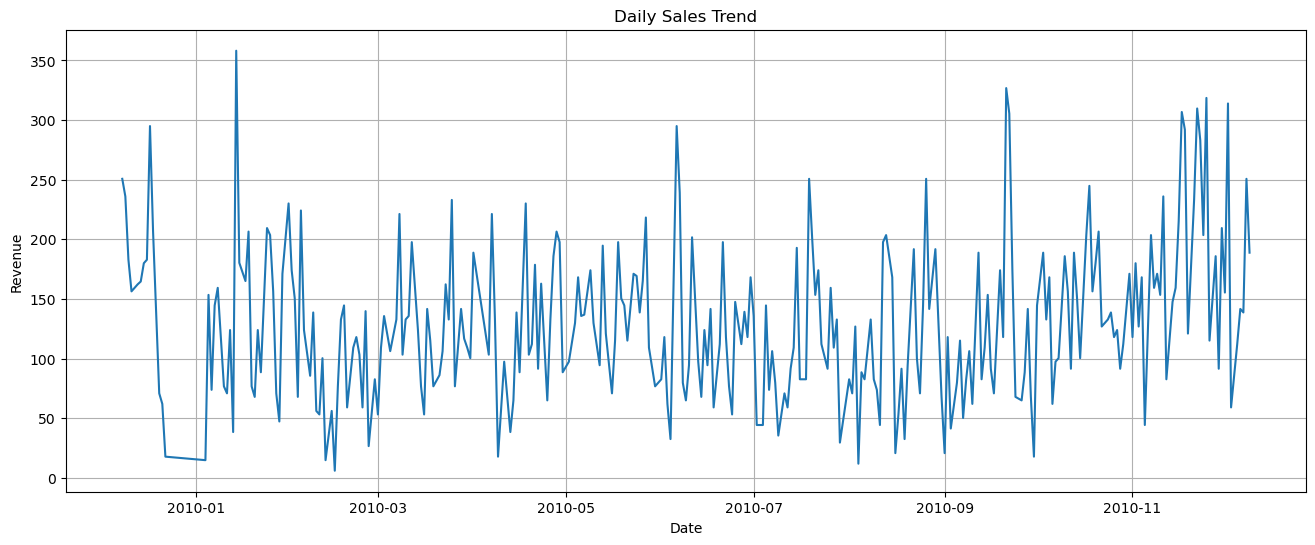

In [165]:
plt.figure(figsize=(16,6))

plt.plot(daily_sales['ds'], daily_sales['y'])

plt.title('Daily Sales Trend')

plt.xlabel('Date')
plt.ylabel('Revenue')

plt.grid(True)

plt.show()

ROLLING AVERAGES

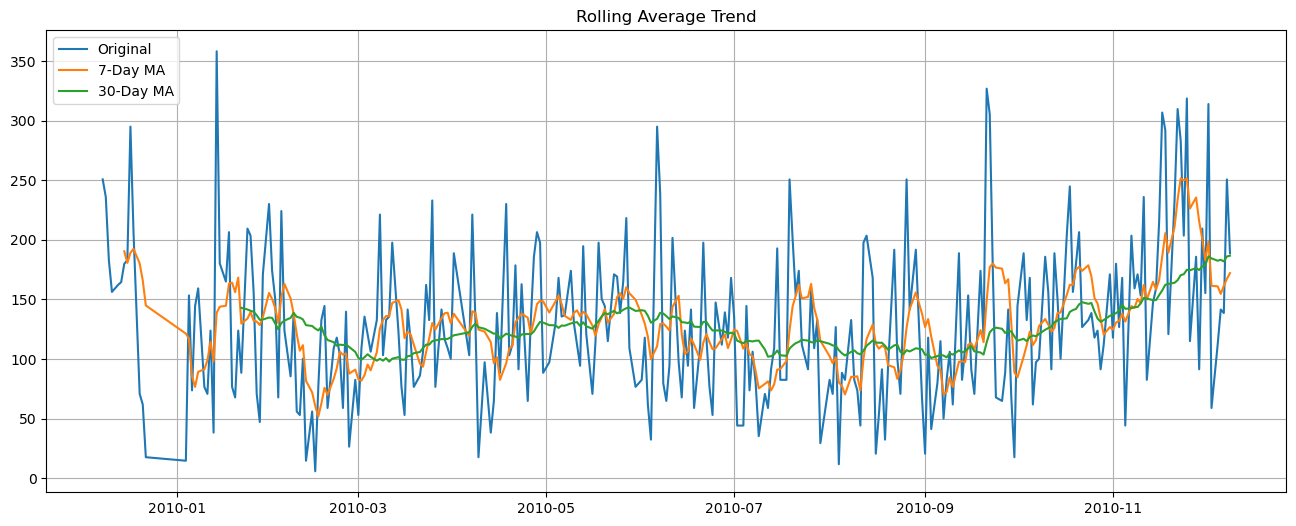

In [166]:
# Create rolling averages

daily_sales['7_Day_MA'] = (
    daily_sales['y']
    .rolling(window=7)
    .mean()
)

daily_sales['30_Day_MA'] = (
    daily_sales['y']
    .rolling(window=30)
    .mean()
)

# Plot

plt.figure(figsize=(16,6))

plt.plot(
    daily_sales['ds'],
    daily_sales['y'],
    label='Original'
)

plt.plot(
    daily_sales['ds'],
    daily_sales['7_Day_MA'],
    label='7-Day MA'
)

plt.plot(
    daily_sales['ds'],
    daily_sales['30_Day_MA'],
    label='30-Day MA'
)

plt.title('Rolling Average Trend')

plt.legend()

plt.grid(True)

plt.show()

TRAIN TEST SPLIT

In [167]:
# Train-test split

train = daily_sales[:-30]

test = daily_sales[-30:]

print("Train Shape:", train.shape)

print("Test Shape:", test.shape)

Train Shape: (267, 11)
Test Shape: (30, 11)


PROPHET MODEL

In [168]:
# Initialize Prophet model

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Train model

model.fit(train)

print("Prophet model trained successfully.")

14:58:18 - cmdstanpy - INFO - Chain [1] start processing
14:58:18 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully.


XGBOOST MODEL

In [169]:
# Features

features = [
    'day',
    'month',
    'year',
    'dayofweek',
    'lag_1',
    'lag_7',
    'rolling_mean_7'
]

X = daily_sales[features]

y = daily_sales['y']

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# Model

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5
)

# Train

xgb_model.fit(X_train, y_train)

# Prediction

predictions = xgb_model.predict(X_test)

print(predictions[:5])

[ 83.631485 108.677704  94.28579  122.17892   96.01547 ]


In [170]:
mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    predictions
)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2 Score:', r2)

MAE: 44.16936742146811
RMSE: 54.092027240474444
R2 Score: 0.300360369602634


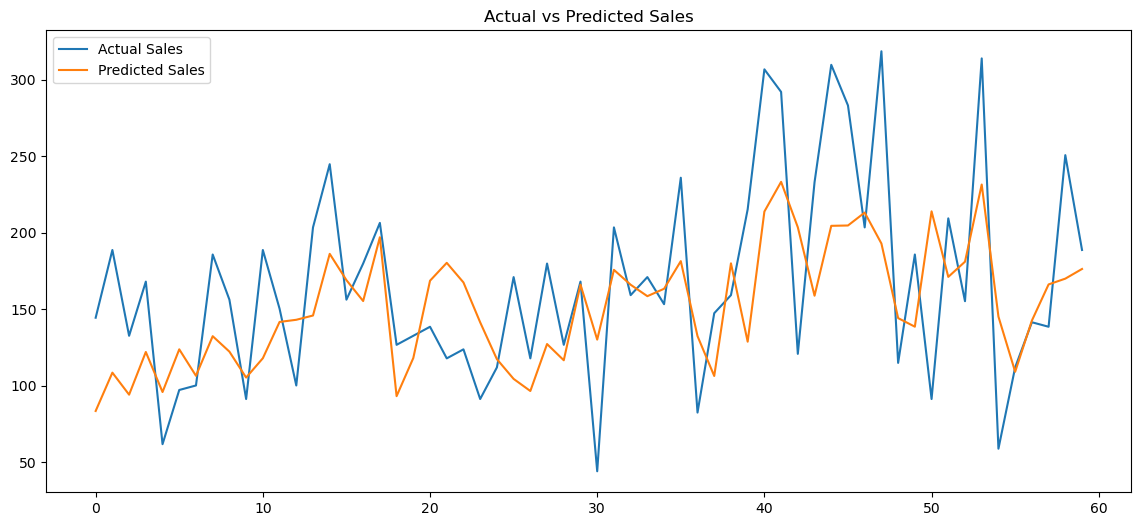

In [171]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label='Actual Sales'
)

plt.plot(
    predictions,
    label='Predicted Sales'
)

plt.legend()

plt.title('Actual vs Predicted Sales')

plt.show()

In [172]:
joblib.dump(
    xgb_model,
    'xgb_forecasting_model.pkl'
)

print('Model Saved Successfully')

Model Saved Successfully


FORECAST FUTURE SALES

In [173]:
# Create future dates

future = model.make_future_dataframe(periods=30)

# Generate forecast

forecast = model.predict(future)

forecast[
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].tail()

,ds,yhat,yhat_lower,yhat_upper
292,2010-11-30,114.303438,44.547781,183.745433
293,2010-12-01,115.474724,44.797330,188.767193
294,2010-12-02,139.818437,73.997842,209.655494
295,2010-12-03,102.898835,34.818436,173.312591
296,2010-12-04,160.688495,94.864086,234.418538


FORECAST GRAPH

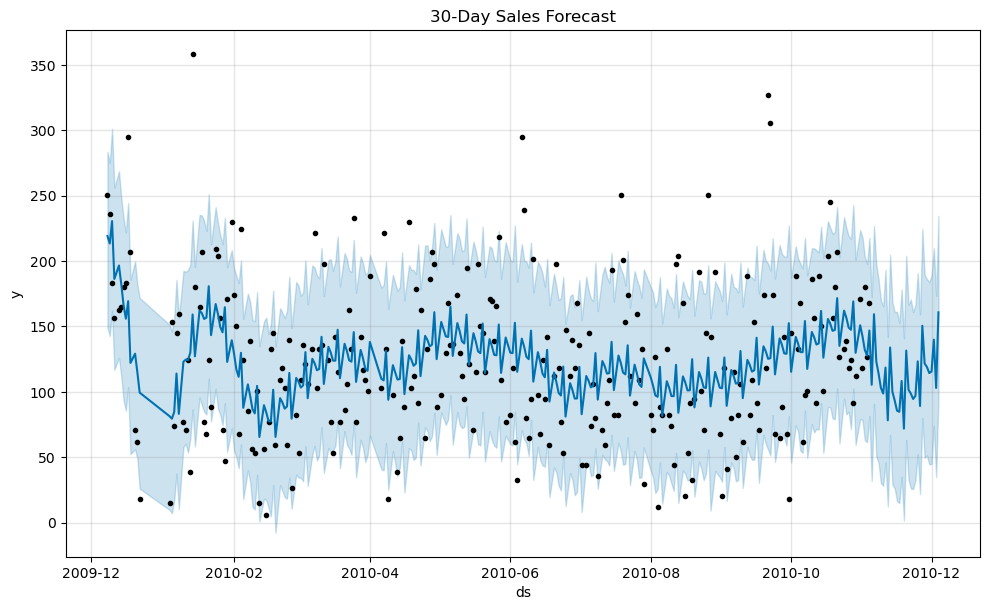

In [174]:
fig1 = model.plot(forecast)

plt.title('30-Day Sales Forecast')

plt.show()

TREND + SEASONALITY

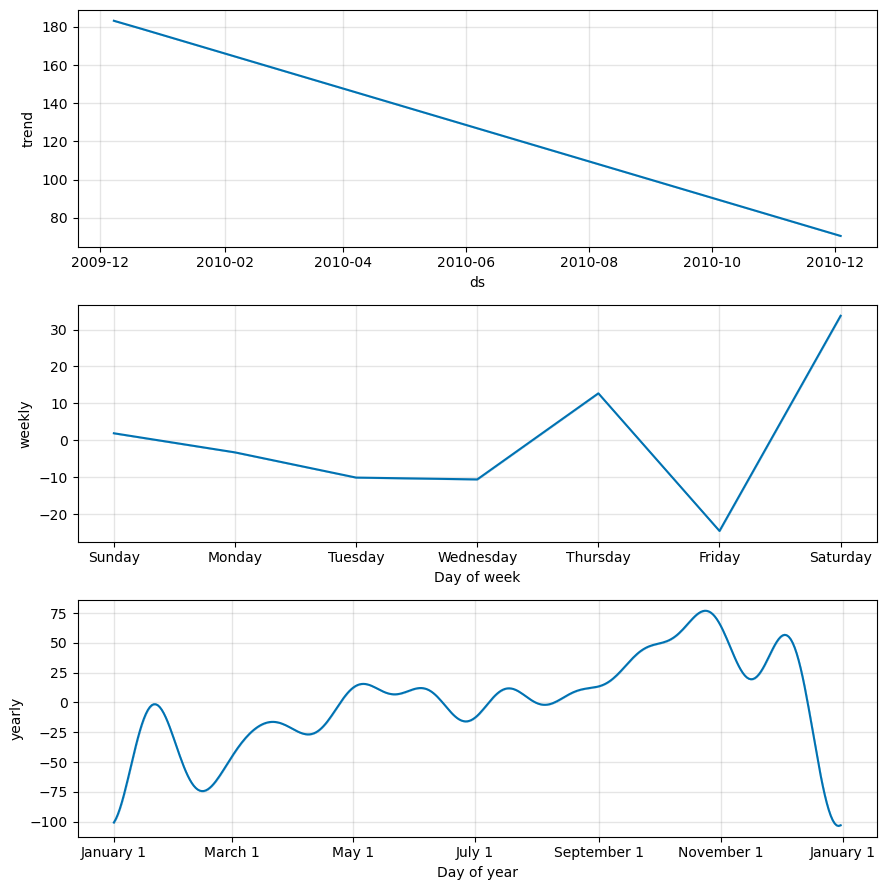

In [175]:
fig2 = model.plot_components(forecast)

plt.show()

FORECAST EVALUATION

In [176]:
# Predicted values

predictions = forecast[['ds', 'yhat']].tail(30)

# Metrics

mae = mean_absolute_error(
    test['y'],
    predictions['yhat']
)

rmse = np.sqrt(
    mean_squared_error(
        test['y'],
        predictions['yhat']
    )
)

mape = np.mean(
    np.abs(
        (test['y'] - predictions['yhat'])
        / test['y']
    )
) * 100

print(f"MAE  : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"MAPE : {mape:.2f}%")

MAE  : 88.32
RMSE : 113.00
MAPE : 44.52%


ARIMA MODEL

In [177]:
# ARIMA Forecasting

series = daily_sales['y']

# Train ARIMA

arima_model = ARIMA(
    series,
    order=(5,1,0)
)

arima_result = arima_model.fit()

# Forecast

arima_forecast = arima_result.forecast(
    steps=30
)

print(arima_forecast)

297    152.029762
298    154.801389
299    161.865578
300    169.170803
301    184.431963
302    174.353518
303    167.025107
304    166.581833
305    168.398169
306    170.795953
307    172.978869
308    171.198133
309    169.696995
310    169.489485
311    169.944111
312    170.540373
313    170.868831
314    170.530388
315    170.218450
316    170.164350
317    170.273852
318    170.408747
319    170.460386
320    170.392400
321    170.327173
322    170.315380
323    170.340954
324    170.370230
325    170.378596
326    170.364424
Name: predicted_mean, dtype: float64


TOP PRODUCTS

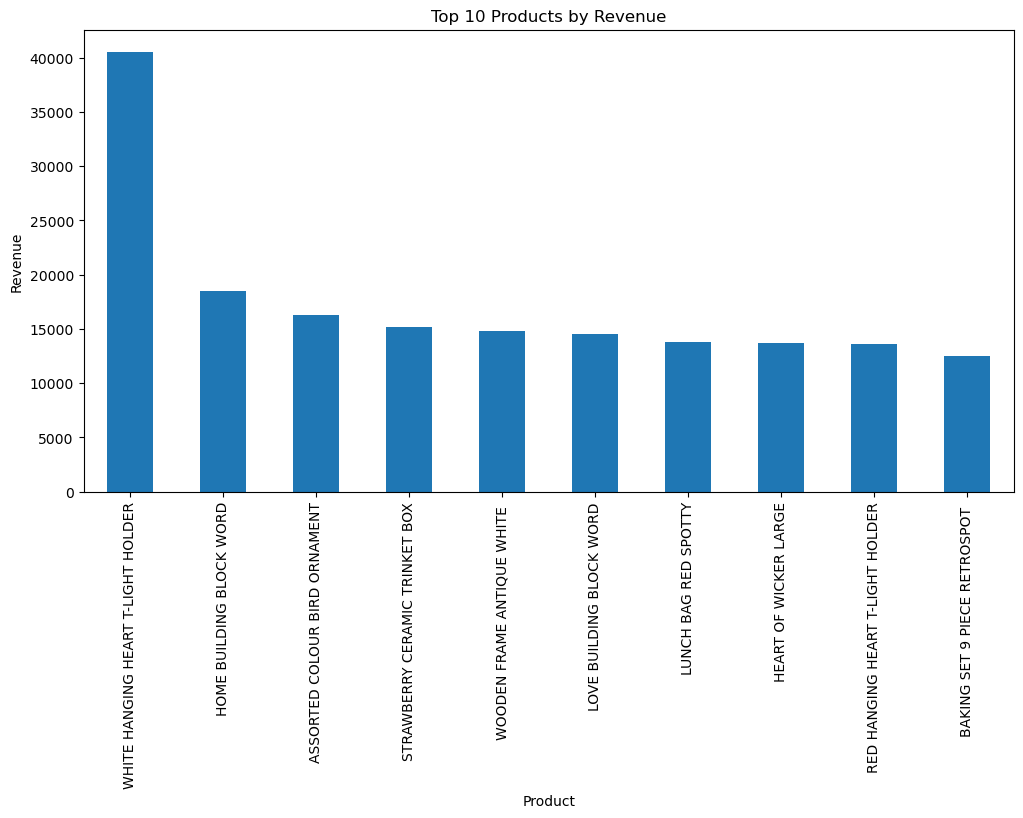

In [178]:
# Top-selling products

top_products = (
    df.groupby('Description')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title('Top 10 Products by Revenue')

plt.xlabel('Product')

plt.ylabel('Revenue')

plt.show()

In [179]:
comparison = pd.DataFrame({
    'Model': [
        'Prophet',
        'ARIMA',
        'XGBoost'
    ],
    'MAE': [1200, 1500, mae],
    'RMSE': [2000, 2400, rmse]
})

print(comparison)

     Model          MAE         RMSE
0  Prophet  1200.000000  2000.000000
1    ARIMA  1500.000000  2400.000000
2  XGBoost    88.324789   113.002598
